<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/lab 12 - Fine-tuning ResNet pretrained vs scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Fine-tuning a ResNet: pre-trained or from scratch? (satellite images)

You have a few hundred labelled images and a ResNet. There are two ways to start:

- **From scratch**: random weights. Everything the network knows has to be learned from your images.
- **Pre-trained**: weights learned on ImageNet (1.28 million photos, 1,000 classes), then adapted to your task. This is **transfer learning**.

Same architecture, same data, same training code. Only the starting weights, and which of them we update, change. How much does it matter, when does it matter, and what can go wrong?

The images are deliberately *not* ImageNet-like: **EuroSAT**, 27,000 satellite photos (Sentinel-2, $64 \times 64$ pixels) of 10 land-use classes: forest, river, highway, industrial area... ImageNet contains no forests or highways seen from space. Will the knowledge transfer anyway?

**Contents**

1. Setup and data
2. What does an ImageNet network see in a satellite image?
3. One architecture, two starting points
4. Pre-processing and augmentation
5. Zero training: pre-trained features + logistic regression
6. A training function
7. Experiment 1: from scratch
8. Experiment 2: feature extraction (frozen backbone, new head)
9. Experiment 3: fine-tuning (last block, then everything)
10. Comparison on the test set
11. Inside the networks: which weights changed, what the filters look like, the feature space
12. Where do they fail? Confusion matrices
13. How many labels do you need? Accuracy vs training-set size
14. Three ways to break a fine-tune
15. Summary and exercises

Theory: [`notes/neural_networks/03_cnn_transfer_multitask`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/03_cnn_transfer_multitask.html) (section 13, transfer learning; sections 18.4, 18.5, 19.2 and 19.7, the assumptions and what to do with few labels) and [`notes/neural_networks/02_training_optimization_regularization`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/02_training_optimization_regularization.html) (learning-rate schedules, BatchNorm).

**Notation**

| Symbol | Meaning |
|---|---|
| $K = 10$ | number of classes |
| $k$ | labelled training images **per class** (the training set has $10k$ images) |
| $\alpha$ | learning rate |
| backbone | every layer of the ResNet except the last one: it turns an image into a 512-number feature vector |
| head | the last linear layer, $512 \to K$: it turns the features into class scores (logits) |

This lab trains dozens of small networks. On a GPU it takes 10 to 15 minutes (in Colab: *Runtime → Change runtime type → T4 GPU*). On a CPU it would take hours: set `RUN_SWEEP = False` in section 13 and expect 30 to 60 minutes for the rest.

## 1. Setup and data

EuroSAT (Helber et al., 2019, MIT licence) has 27,000 RGB images of $64 \times 64$ pixels, 2,000 to 3,000 per class. There is no official split, so we make one, **stratified** (every class keeps its share):

- **20 % test** (5,400 images): looked at only for the final numbers;
- **10 % validation** (2,700 images): to choose the epoch and to compare settings;
- **70 % pool** (18,900 images): the training sets are drawn from it. The labelled-data budget is a parameter: `subset(k)` returns $k$ images per class.

The whole dataset is $27{,}000 \times 3 \times 64 \times 64$ bytes = 330 MB, so we keep it **on the GPU as one `uint8` tensor** and do the augmentation there. No `DataLoader` is needed.

In [1]:
import copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import EuroSAT
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

dataset = EuroSAT("~/.pytorch/EuroSAT", download=True)        # ~90 MB, downloaded once
class_names = dataset.classes
t0 = time.time()
X = np.stack([np.asarray(img) for img, _ in dataset])         # (27000, 64, 64, 3) uint8
y = np.array(dataset.targets)
print(f"{X.shape[0]} images of {X.shape[1]}x{X.shape[2]}, {len(class_names)} classes  (loaded in {time.time() - t0:.0f} s)")

idx = np.arange(len(y))
rest, test_idx = train_test_split(idx, test_size=0.20, stratify=y, random_state=0)
pool_idx, val_idx = train_test_split(rest, test_size=0.125, stratify=y[rest], random_state=0)   # 0.125 * 80 % = 10 %
print(f"pool {len(pool_idx)}   validation {len(val_idx)}   test {len(test_idx)}")

X_gpu = torch.tensor(X).permute(0, 3, 1, 2).contiguous().to(device)    # (N, 3, 64, 64) uint8, on the GPU
y_gpu = torch.tensor(y).to(device)

def subset(k, seed=0):
    """k training images per class, drawn from the pool: a balanced training set of 10 * k images."""
    rng = np.random.default_rng(seed)
    return np.concatenate([rng.permutation(pool_idx[y[pool_idx] == c])[:k] for c in range(len(class_names))])

print("images per class in the dataset:", {n: int(c) for n, c in zip(class_names, np.bincount(y))})

device: cuda


27000 images of 64x64, 10 classes  (loaded in 4 s)
pool 18900   validation 2700   test 5400
images per class in the dataset: {'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}


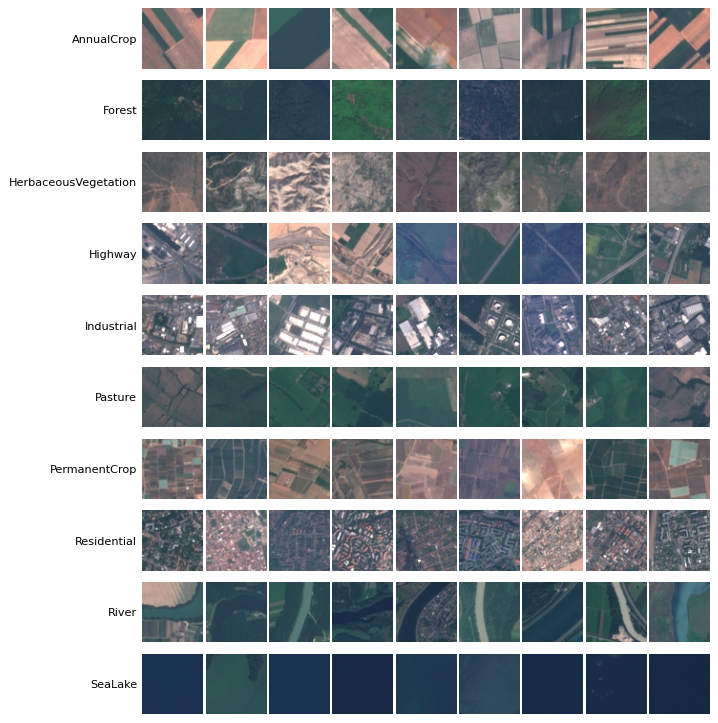

In [2]:
fig, axes = plt.subplots(10, 9, figsize=(9, 10.3))
rng = np.random.default_rng(1)
for c, name in enumerate(class_names):
    ids = rng.choice(np.where(y == c)[0], 9, replace=False)
    for j, i in enumerate(ids):
        axes[c, j].imshow(X[i]); axes[c, j].axis("off")
    axes[c, 0].text(-6, 32, name, ha="right", va="center", fontsize=9)
plt.subplots_adjust(left=0.2, wspace=0.05, hspace=0.05); plt.show()

Some classes are easy to tell apart (sea, forest, highway), some are not: *AnnualCrop*, *PermanentCrop*, *Pasture* and *HerbaceousVegetation* are all fields of different greens. We will see which ones the networks mix up.

## 2. What does an ImageNet network see in a satellite image?

Before any training, let us ask a ResNet-18 pre-trained on ImageNet what it thinks of one test image per class. Its last layer has 1,000 outputs, the ImageNet classes, and none of them is *Forest* or *Highway as seen from above*.

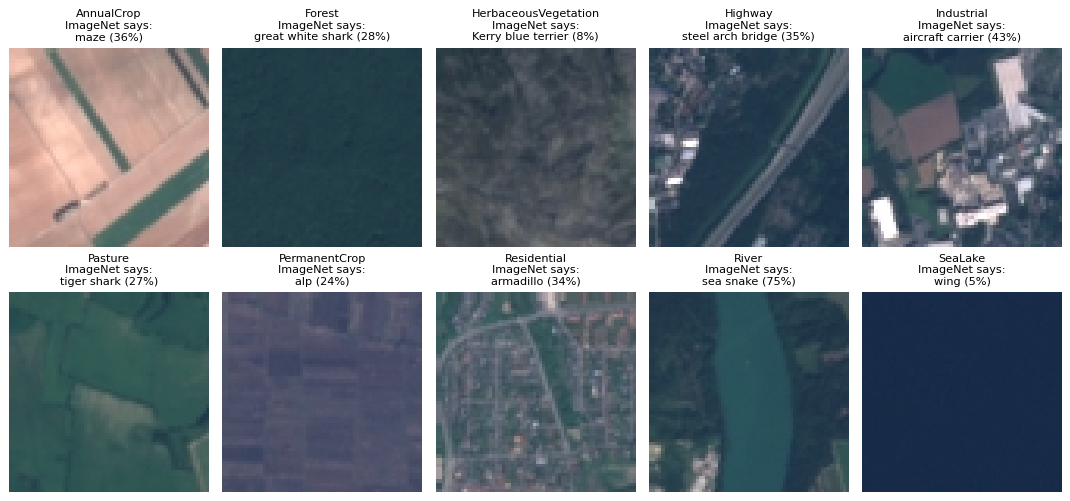

In [3]:
imagenet_weights = ResNet18_Weights.IMAGENET1K_V1
imagenet_net = resnet18(weights=imagenet_weights).to(device).eval()       # the original 1000-class network
categories = imagenet_weights.meta["categories"]

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)    # ImageNet statistics
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
IMG = 96                                                                     # the networks see 96 x 96 images

def prep(xb, train=False, normalize=True):
    """uint8 batch (B, 3, 64, 64) on the device -> float batch (B, 3, IMG, IMG) ready for the network."""
    x = xb.float() / 255
    if train:                                              # augmentation: random flips and quarter turns
        flip = torch.rand(len(x), device=x.device) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), x.flip(3), x)
        turns = torch.randint(0, 4, (len(x),), device=x.device)
        out = x.clone()
        for r in (1, 2, 3):
            m = turns == r
            out[m] = torch.rot90(x[m], r, (2, 3))
        x = out
    x = F.interpolate(x, size=IMG, mode="bilinear", align_corners=False)   # 64 -> 96 pixels
    return (x - MEAN) / STD if normalize else x

ids = [int(np.where(y[test_idx] == c)[0][0]) for c in range(10)]
ids = test_idx[ids]
with torch.no_grad():
    p = imagenet_net(prep(X_gpu[torch.as_tensor(ids, device=device)])).softmax(1)
conf, top = p.max(1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.8))
for ax, i, c, k in zip(axes.ravel(), ids, conf.tolist(), top.tolist()):
    ax.imshow(X[i]); ax.axis("off")
    ax.set_title(f"{class_names[y[i]]}\nImageNet says:\n{categories[k]} ({c:.0%})", fontsize=9)
plt.tight_layout(); plt.show()

The answers are wrong, of course (a shark for a forest, an armadillo for a residential area), but not random: the network says what the shapes and textures remind it of, a maze for ploughed fields, a steel arch bridge for a highway, an aircraft carrier for an industrial area. What matters is not the 1,000-way answer but the **features** behind it, the 512 numbers before the last layer. They describe edges, textures and shapes, and are useful for almost any image. Transfer learning keeps the features and replaces the last layer.

## 3. One architecture, two starting points

A **ResNet-18** has 18 layers with weights: a $7 \times 7$ convolution, four stages of two residual blocks each, and a final linear layer. The only differences between "from scratch" and "pre-trained" are the initial values of the weights. We replace the ImageNet layer (512 → 1000) by a new one (512 → 10) in both cases; it starts random in both.

In [4]:
def make_resnet(pretrained, n_classes=10):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    model.fc = nn.Linear(model.fc.in_features, n_classes)           # the new head: random in both cases
    return model.to(device)

def count_params(params):
    return sum(p.numel() for p in params)

model = make_resnet(pretrained=True)
rows = [("conv1 + bn1", count_params(list(model.conv1.parameters()) + list(model.bn1.parameters())))]
rows += [(f"layer{i} (2 residual blocks)", count_params(getattr(model, f"layer{i}").parameters())) for i in range(1, 5)]
rows += [("fc (512 -> 10)", count_params(model.fc.parameters()))]
table = pd.DataFrame(rows, columns=["part", "parameters"])
table["share"] = (100 * table["parameters"] / table["parameters"].sum()).round(1).astype(str) + " %"
print(table.to_string(index=False))
print("total:", count_params(model.parameters()))

                      part  parameters  share
               conv1 + bn1        9536  0.1 %
layer1 (2 residual blocks)      147968  1.3 %
layer2 (2 residual blocks)      525568  4.7 %
layer3 (2 residual blocks)     2099712 18.8 %
layer4 (2 residual blocks)     8393728 75.1 %
            fc (512 -> 10)        5130  0.0 %
total: 11181642


Almost all the parameters are in the last stages, which see small, abstract feature maps, and the head we train from nothing is just 5,130 numbers.

The first layer shows the difference between the two starting points. Its 64 filters ($7 \times 7$ pixels, 3 colour channels) are the first thing the image meets:

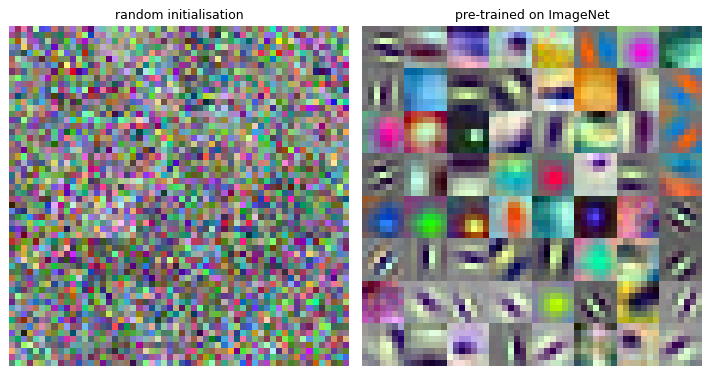

In [5]:
def show_filters(ax, model, title):
    w = model.conv1.weight.detach().cpu()                          # (64, 3, 7, 7)
    w = (w - w.amin(dim=(1, 2, 3), keepdim=True)) / (w.amax(dim=(1, 2, 3), keepdim=True) - w.amin(dim=(1, 2, 3), keepdim=True))
    grid = w.view(8, 8, 3, 7, 7).permute(0, 3, 1, 4, 2).reshape(8 * 7, 8 * 7, 3)
    ax.imshow(grid.numpy(), interpolation="nearest"); ax.axis("off"); ax.set_title(title, fontsize=10)

torch.manual_seed(0)
fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
show_filters(axes[0], make_resnet(False), "random initialisation")
show_filters(axes[1], make_resnet(True), "pre-trained on ImageNet")
plt.tight_layout(); plt.show()

Random filters are noise. The pre-trained ones are **edge detectors** at many orientations and **colour blobs**, the same first-layer patterns that the lab on CNNs found on Fashion-MNIST, and that biological vision seems to use too. A network from scratch has to discover them from our images alone.

## 4. Pre-processing and augmentation

Two rules for a pre-trained network (notes 03, sections 13.2 and 18.4):

1. **Feed the images as in pre-training**: pixels in $[0,1]$, then subtract the ImageNet channel mean and divide by the ImageNet standard deviation. The filters expect inputs on that scale. We also enlarge the $64 \times 64$ images to $96 \times 96$ so that objects have roughly the size the network is used to.
2. **Augment only with transformations that keep the label.** Satellite images have no "up": a forest seen from above is a forest when flipped or turned by 90°. So we use random horizontal flips and random quarter turns (8 versions of every image, for free), the answer to exercise 5 of the CNN lab.

`prep` (defined above) does both, on the GPU. Here are 8 versions of one image:

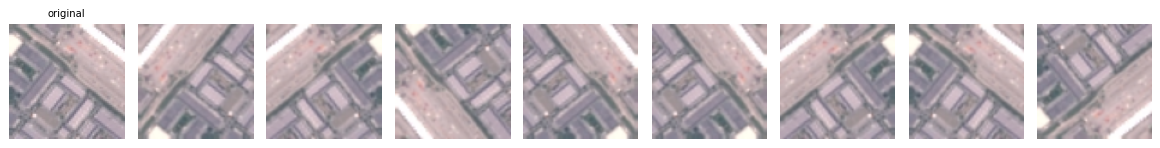

after the transform, per channel:  mean [-0.62 -0.34 -0.  ]  std [0.87 0.58 0.49]


In [6]:
i = int(np.where(y == 4)[0][3])                                      # an industrial area
torch.manual_seed(3)
batch = prep(X_gpu[i].unsqueeze(0).repeat(8, 1, 1, 1), train=True, normalize=False).cpu()
fig, axes = plt.subplots(1, 9, figsize=(13, 1.8))
axes[0].imshow(X[i]); axes[0].set_title("original", fontsize=8)
for ax, im in zip(axes[1:], batch):
    ax.imshow(im.permute(1, 2, 0).numpy())
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

xb = prep(X_gpu[torch.as_tensor(subset(50), device=device)])         # a batch with the ImageNet normalisation
print("after the transform, per channel:  mean", xb.mean(dim=(0, 2, 3)).cpu().numpy().round(2),
      " std", xb.std(dim=(0, 2, 3)).cpu().numpy().round(2))

The statistics are not exactly 0 and 1, because satellite images are darker and less contrasted than ImageNet photos, but they are on the scale the pre-trained filters expect. Skipping the normalisation costs accuracy; section 14 measures how much.

## 5. Zero training: pre-trained features + logistic regression

How good are the pre-trained features **before we train the CNN at all**? Take the 512 numbers that the backbone produces for each image and fit an ordinary logistic regression on them (the ML part of the course), with a small training set: $k = 50$ images per class, 500 in total. Compare with a ResNet that has *random* weights: its features are random projections of the image.

In [7]:
def features(model, idx, batch=500):
    """The 512-dimensional vector before the last layer (global average pooling), for the images idx."""
    model.eval()
    head, model.fc = model.fc, nn.Identity()
    out = []
    with torch.no_grad():
        for i in range(0, len(idx), batch):
            b = torch.as_tensor(idx[i:i + batch], device=device)
            out.append(model(prep(X_gpu[b])).float().cpu())
    model.fc = head
    return torch.cat(out).numpy()

train_idx = subset(50)                                   # the labelled-data budget of the main experiments
print("training images:", len(train_idx), " (50 per class)")

zero_train = {}
for name, pretrained in [("random weights", False), ("ImageNet weights", True)]:
    torch.manual_seed(0)
    net = make_resnet(pretrained)
    f_tr, f_te = features(net, train_idx), features(net, test_idx)
    mu, sd = f_tr.mean(0), f_tr.std(0) + 1e-6
    clf = LogisticRegression(max_iter=3000, C=0.5).fit((f_tr - mu) / sd, y[train_idx])
    zero_train[name] = clf.score((f_te - mu) / sd, y[test_idx])
    print(f"{name:17s} features + logistic regression: test accuracy {zero_train[name]:.3f}")

training images: 500  (50 per class)


random weights    features + logistic regression: test accuracy 0.546


ImageNet weights  features + logistic regression: test accuracy 0.859


With **no gradient step on the CNN**, the ImageNet features already classify the satellite images far better than random features do. This is the cheapest transfer learning there is, and the baseline every other method has to beat. The rest of the lab trains the network itself.

## 6. A training function

One function for every experiment; only its arguments change. It trains with AdamW and a **one-cycle schedule** (learning rate warm-up for 15 % of the steps, then a smooth decay; notes 02, section 5). The warm-up matters for fine-tuning: it keeps the first steps, taken with a random head, from damaging the pre-trained weights.

- `groups` are the parameter groups with their learning rates: this is how we freeze layers (leave them out), and how we give the backbone a smaller learning rate than the head (**discriminative learning rates**).
- `bn_eval=True` keeps the BatchNorm layers of a frozen backbone in evaluation mode (see section 14).
- At the end it restores the epoch with the lowest **validation** loss. The test set is never used for any choice.

In [8]:
def evaluate(model, idx, normalize=True, batch=1000, return_preds=False):
    model.eval()
    total, correct, preds = 0.0, 0, []
    with torch.no_grad():
        for i in range(0, len(idx), batch):
            b = torch.as_tensor(idx[i:i + batch], device=device)
            logits = model(prep(X_gpu[b], normalize=normalize))
            total += F.cross_entropy(logits, y_gpu[b], reduction="sum").item()
            correct += (logits.argmax(1) == y_gpu[b]).sum().item()
            preds.append(logits.argmax(1).cpu())
    out = (total / len(idx), correct / len(idx))
    return out + (torch.cat(preds).numpy(),) if return_preds else out

def head_params(model): return list(model.fc.parameters())
def body_params(model): return [p for n, p in model.named_parameters() if not n.startswith("fc.")]

def freeze(params):
    for p in params: p.requires_grad = False

def fit(model, train_idx, epochs, groups, batch=64, bn_eval=False, normalize=True, weight_decay=1e-4,
        track=True, verbose=True):
    """Train `model` on the images train_idx. groups: [{"params": ..., "lr": ...}, ...]"""
    model.to(device)
    opt = torch.optim.AdamW(groups, weight_decay=weight_decay)
    steps = epochs * int(np.ceil(len(train_idx) / batch))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g["lr"] for g in groups], total_steps=steps,
                                                pct_start=0.15, cycle_momentum=False)
    hist = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}
    best, t0 = (float("inf"), None, 0), time.time()
    train_t = torch.as_tensor(train_idx, device=device)
    for epoch in range(epochs):
        model.train()
        if bn_eval:                                         # frozen backbone: keep its BatchNorm statistics fixed
            for m in model.modules():
                if isinstance(m, nn.BatchNorm2d): m.eval()
        perm = train_t[torch.randperm(len(train_t), device=device)]
        tot, correct = 0.0, 0
        for i in range(0, len(perm), batch):
            b = perm[i:i + batch]
            if len(b) < 2: continue                         # BatchNorm needs more than one example
            logits = model(prep(X_gpu[b], train=True, normalize=normalize))
            loss = F.cross_entropy(logits, y_gpu[b])
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step()
            tot += loss.item() * len(b); correct += (logits.argmax(1) == y_gpu[b]).sum().item()
        hist["train_loss"].append(tot / len(perm)); hist["train_acc"].append(correct / len(perm))
        if track:
            vl, va = evaluate(model, val_idx, normalize)
            hist["val_loss"].append(vl); hist["val_acc"].append(va)
            if vl < best[0]: best = (vl, copy.deepcopy(model.state_dict()), epoch)
            if verbose and ((epoch + 1) % max(1, epochs // 6) == 0 or epoch == epochs - 1):
                print(f"epoch {epoch + 1:3d}  train loss {tot / len(perm):.3f} acc {correct / len(perm):.3f}   "
                      f"val loss {vl:.3f} acc {va:.3f}")
    if track:
        model.load_state_dict(best[1])
        hist["best_epoch"] = best[2]
        if verbose: print(f"-> restored epoch {best[2] + 1}: val loss {best[0]:.3f}, val acc {hist['val_acc'][best[2]]:.3f}")
    hist["time"] = time.time() - t0
    hist["epochs"] = epochs
    hist["trainable"] = count_params(p for g in groups for p in g["params"])
    return hist

## 7. Experiment 1: from scratch

Random weights, all 11.2 million of them trained on 500 images (50 per class). A scratch network needs more epochs than a fine-tuned one, since it has everything to learn, so we give it 60 epochs against 15 or 30 for the others.

In [9]:
torch.manual_seed(0)
net_scratch = make_resnet(pretrained=False)
hist_scratch = fit(net_scratch, train_idx, epochs=60, groups=[{"params": net_scratch.parameters(), "lr": 1e-3}])

epoch  10  train loss 0.944 acc 0.660   val loss 2.536 acc 0.487


epoch  20  train loss 0.687 acc 0.772   val loss 1.495 acc 0.554


epoch  30  train loss 0.430 acc 0.828   val loss 1.168 acc 0.636


epoch  40  train loss 0.224 acc 0.918   val loss 0.852 acc 0.743


epoch  50  train loss 0.086 acc 0.984   val loss 0.672 acc 0.817


epoch  60  train loss 0.083 acc 0.968   val loss 0.680 acc 0.816
-> restored epoch 54: val loss 0.672, val acc 0.821


## 8. Experiment 2: feature extraction (frozen backbone, new head)

Start from the ImageNet weights, **freeze the whole backbone** (`requires_grad = False`) and train only the new head: 5,130 parameters instead of 11.2 million. The backbone is a fixed feature extractor, as in section 5, but now the head is trained by gradient descent with the augmentation on.

`bn_eval=True` keeps the frozen backbone's BatchNorm layers in evaluation mode: a frozen layer should not change at all (section 14 shows what happens otherwise).

In [10]:
torch.manual_seed(0)
net_frozen = make_resnet(pretrained=True)
freeze(body_params(net_frozen))
hist_frozen = fit(net_frozen, train_idx, epochs=30, bn_eval=True,
                  groups=[{"params": head_params(net_frozen), "lr": 1e-2}])
print("trainable parameters:", hist_frozen["trainable"])

epoch   5  train loss 0.304 acc 0.896   val loss 0.489 acc 0.848


epoch  10  train loss 0.133 acc 0.964   val loss 0.410 acc 0.881


epoch  15  train loss 0.126 acc 0.960   val loss 0.405 acc 0.879


epoch  20  train loss 0.073 acc 0.988   val loss 0.425 acc 0.873


epoch  25  train loss 0.077 acc 0.978   val loss 0.420 acc 0.880


epoch  30  train loss 0.077 acc 0.988   val loss 0.416 acc 0.880
-> restored epoch 15: val loss 0.405, val acc 0.879
trainable parameters: 5130


## 9. Experiment 3: fine-tuning

Between "train nothing but the head" and "train everything" there is a dial. We try two settings, both with **discriminative learning rates**: the pre-trained layers are already good, so they move slowly ($\alpha = 10^{-4}$); the new head starts random, so it moves faster ($\alpha = 10^{-3}$).

- **Last block + head**: freeze everything up to `layer3`; train `layer4` and the head.
- **Everything**: all layers trainable, backbone at $10^{-4}$, head at $10^{-3}$.

In [11]:
torch.manual_seed(0)
net_last = make_resnet(pretrained=True)
freeze(body_params(net_last))
for p in net_last.layer4.parameters(): p.requires_grad = True              # unfreeze the last block
hist_last = fit(net_last, train_idx, epochs=15, bn_eval=True,
                groups=[{"params": net_last.layer4.parameters(), "lr": 1e-4}, {"params": head_params(net_last), "lr": 1e-3}])
print("trainable parameters:", hist_last["trainable"])

epoch   2  train loss 1.420 acc 0.566   val loss 0.676 acc 0.799
epoch   4  train loss 0.334 acc 0.880   val loss 0.448 acc 0.858


epoch   6  train loss 0.181 acc 0.936   val loss 0.318 acc 0.892
epoch   8  train loss 0.121 acc 0.954   val loss 0.303 acc 0.901


epoch  10  train loss 0.070 acc 0.980   val loss 0.310 acc 0.906
epoch  12  train loss 0.048 acc 0.986   val loss 0.298 acc 0.908


epoch  14  train loss 0.053 acc 0.992   val loss 0.285 acc 0.914
epoch  15  train loss 0.036 acc 0.992   val loss 0.285 acc 0.914
-> restored epoch 13: val loss 0.283, val acc 0.914
trainable parameters: 8398858


In [12]:
torch.manual_seed(0)
net_full = make_resnet(pretrained=True)
hist_full = fit(net_full, train_idx, epochs=15,
                groups=[{"params": body_params(net_full), "lr": 1e-4}, {"params": head_params(net_full), "lr": 1e-3}])
print("trainable parameters:", hist_full["trainable"])

epoch   2  train loss 1.603 acc 0.538   val loss 1.256 acc 0.662


epoch   4  train loss 0.412 acc 0.878   val loss 0.466 acc 0.872


epoch   6  train loss 0.159 acc 0.950   val loss 0.311 acc 0.901
epoch   8  train loss 0.105 acc 0.974   val loss 0.283 acc 0.905


epoch  10  train loss 0.079 acc 0.982   val loss 0.254 acc 0.913
epoch  12  train loss 0.059 acc 0.990   val loss 0.245 acc 0.917


epoch  14  train loss 0.060 acc 0.986   val loss 0.242 acc 0.918
epoch  15  train loss 0.060 acc 0.988   val loss 0.241 acc 0.917
-> restored epoch 15: val loss 0.241, val acc 0.917
trainable parameters: 11181642


## 10. Comparison on the test set

The learning curves first. Note the horizontal axis: the scratch network is given 4 times more epochs than the fine-tuned ones and still ends below them.

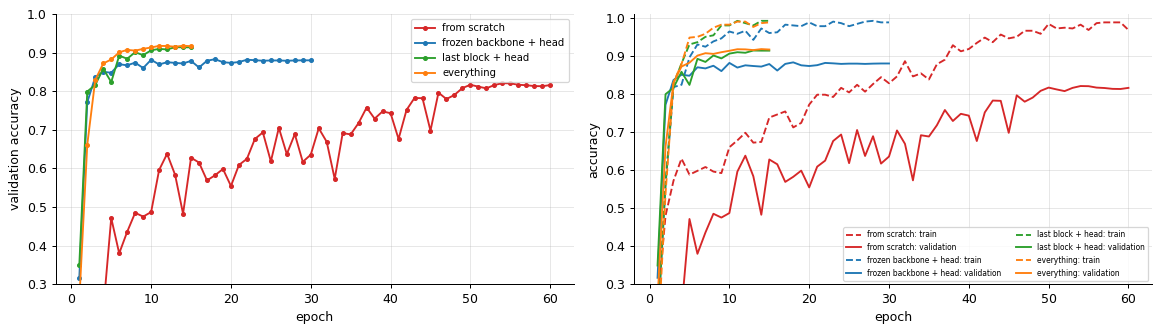

In [13]:
runs = {"from scratch": hist_scratch, "frozen backbone + head": hist_frozen,
        "last block + head": hist_last, "everything": hist_full}
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for (name, h), c in zip(runs.items(), ["C3", "C0", "C2", "C1"]):
    ep = np.arange(1, len(h["val_acc"]) + 1)
    axes[0].plot(ep, h["val_acc"], "o-", ms=3, color=c, label=name)
    axes[1].plot(ep, h["train_acc"], "--", color=c, label=f"{name}: train")
    axes[1].plot(ep, h["val_acc"], "-", color=c, label=f"{name}: validation")
axes[0].set_ylabel("validation accuracy"); axes[1].set_ylabel("accuracy")
axes[0].set_ylim(0.3, 1); axes[1].set_ylim(0.3, 1.01)
for ax in axes: ax.set_xlabel("epoch")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

In [14]:
nets = {"from scratch": net_scratch, "frozen backbone + head": net_frozen,
        "last block + head": net_last, "everything": net_full}
rows = [("(no CNN training) ImageNet features + logistic regression", "-", "-", "-", None, zero_train["ImageNet weights"])]
for (name, net), (_, h) in zip(nets.items(), runs.items()):
    _, val_acc = evaluate(net, val_idx)
    _, test_acc = evaluate(net, test_idx)
    rows.append((name, f"{h['trainable']:,}", h["epochs"], f"{h['time']:.0f} s", val_acc, test_acc))
results = pd.DataFrame(rows, columns=["method", "trainable params", "epochs", "time", "val acc", "test acc"])
results["val acc"] = results["val acc"].map(lambda v: "-" if v is None else f"{v:.3f}")
results["test acc"] = results["test acc"].map(lambda v: f"{v:.3f}")
print(results.to_string(index=False))

                                                   method trainable params epochs time val acc test acc
(no CNN training) ImageNet features + logistic regression                -      -    -     nan    0.859
                                             from scratch       11,181,642     60  6 s   0.821    0.809
                                   frozen backbone + head            5,130     30  2 s   0.879    0.876
                                        last block + head        8,398,858     15  1 s   0.914    0.917
                                               everything       11,181,642     15  1 s   0.917    0.930


**Reading the table.**

- **Pre-trained beats scratch by a wide margin** on 500 images (about 93 % against 81 %), in a domain that has nothing to do with ImageNet. The scratch network overfits: its training accuracy reaches 97 % while its validation accuracy stays near 82 %, and its validation curve is erratic, because a random network with BatchNorm is sensitive to the large learning rates of the first epochs.
- **A frozen backbone is clearly better than scratch** (about 88 % against 81 %) and trains in a couple of seconds, but it is limited by features that were never adapted to satellite images.
- **Adapting the last block** (about 92 %) recovers most of the gap between the frozen backbone and **adapting everything** with a small learning rate (about 93 %), the best of the four.
- The fine-tuned networks are above 90 % validation accuracy after 8 epochs. The scratch network, with four times more epochs, never gets there.

## 11. Inside the networks

**Which weights moved?** Fine-tuning started from the ImageNet weights, so we can measure, for every convolution, how much it changed: $\lVert W_{\text{after}} - W_{\text{before}} \rVert / \lVert W_{\text{before}} \rVert$.

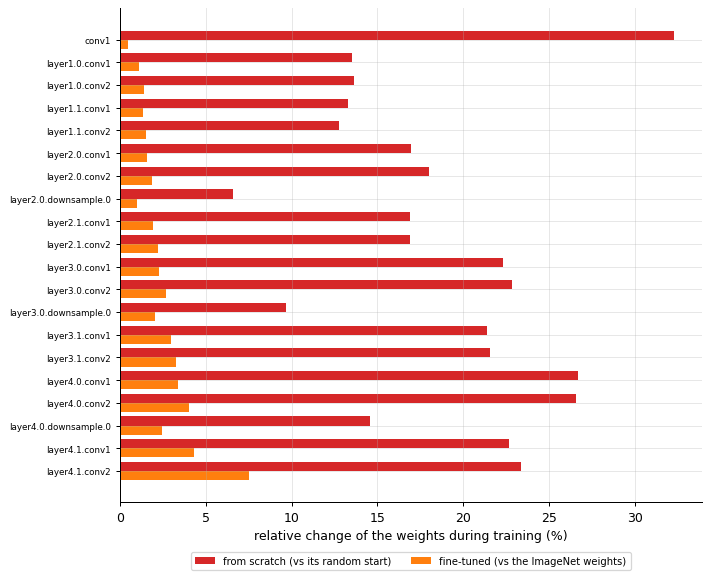

first convolution:  scratch 32 %   fine-tuned 0.5 %
last convolution:   scratch 23 %   fine-tuned 7.5 %


In [15]:
torch.manual_seed(0)
init_scratch = make_resnet(pretrained=False).state_dict()      # the random start of section 7 (same seed)
init_pretrained = make_resnet(pretrained=True).state_dict()    # the ImageNet weights, before any training

def relative_change(net, start):
    names, change = [], []
    for n, p in net.named_parameters():
        if p.ndim == 4:                                         # the convolutions
            names.append(n.replace(".weight", "")); change.append(100 * ((p.detach() - start[n]).norm() / start[n].norm()).item())
    return names, np.array(change)

names, change_scratch = relative_change(net_scratch, init_scratch)
_, change_full = relative_change(net_full, init_pretrained)
fig, ax = plt.subplots(figsize=(8, 6.5))
pos = np.arange(len(names))
ax.barh(pos - 0.2, change_scratch, height=0.4, color="C3", label="from scratch (vs its random start)")
ax.barh(pos + 0.2, change_full, height=0.4, color="C1", label="fine-tuned (vs the ImageNet weights)")
ax.set_yticks(pos); ax.set_yticklabels(names, fontsize=7); ax.invert_yaxis()
ax.set_xlabel("relative change of the weights during training (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2, fontsize=8)
plt.tight_layout(); plt.show()
print(f"first convolution:  scratch {change_scratch[0]:.0f} %   fine-tuned {change_full[0]:.1f} %")
print(f"last convolution:   scratch {change_scratch[-1]:.0f} %   fine-tuned {change_full[-1]:.1f} %")

Training from scratch has to move **every** layer a long way (most layers change by 15 to 30 % of their size). Fine-tuning moves the first layers by about 1 % and the last block by 3 to 8 %, growing with depth: the edges and textures of ImageNet are good enough for satellite images as they are, and the adaptation happens in the deep, task-specific layers. This is why freezing the early layers loses so little, and why a small learning rate is enough.

**What do the first-layer filters look like?** The same $7 \times 7$ filters as in section 3, after training on our 500 images:

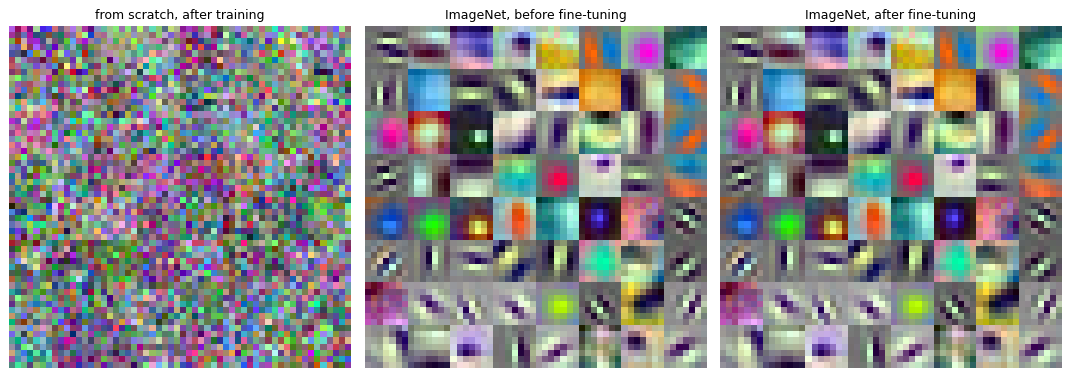

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
show_filters(axes[0], net_scratch, "from scratch, after training")
show_filters(axes[1], make_resnet(True), "ImageNet, before fine-tuning")
show_filters(axes[2], net_full, "ImageNet, after fine-tuning")
plt.tight_layout(); plt.show()

The scratch filters moved a lot (section above) but are still noise: 500 images do not contain enough information to shape them into clean edge detectors, so most of the change is noise fitted to the training set. The fine-tuned filters are the ImageNet ones, essentially untouched.

**What does the feature space look like?** We map the 512 features of 1,000 test images (100 per class) to 2-D with t-SNE: images close together have similar features. If the features separate the classes, a linear head can read them.

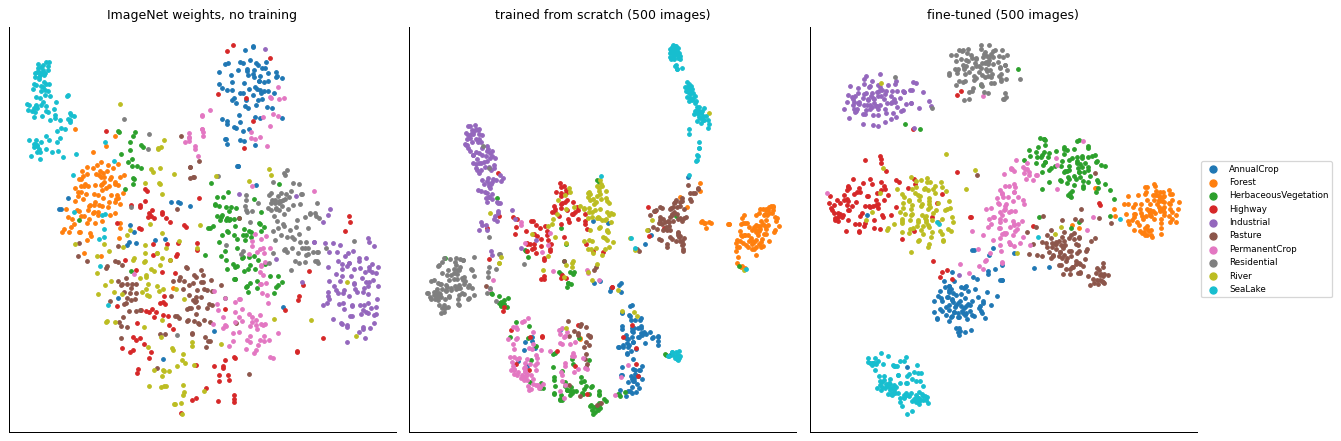

In [17]:
from sklearn.manifold import TSNE
rng = np.random.default_rng(0)
tsne_idx = np.concatenate([rng.choice(test_idx[y[test_idx] == c], 100, replace=False) for c in range(10)])
torch.manual_seed(0)
spaces = {"ImageNet weights, no training": make_resnet(True), "trained from scratch (500 images)": net_scratch,
          "fine-tuned (500 images)": net_full}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, net) in zip(axes, spaces.items()):
    emb = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(features(net, tsne_idx))
    for c in range(10):
        m = y[tsne_idx] == c
        ax.scatter(emb[m, 0], emb[m, 1], s=8, color=plt.cm.tab10(c), label=class_names[c])
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
axes[2].legend(fontsize=7, markerscale=2, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout(); plt.show()

Even **before any training**, the ImageNet features already set apart the sea, the forest, the annual crops and the industrial areas; the other classes overlap. After fine-tuning the ten clusters are compact and mostly separate (the crop and vegetation classes touch). The scratch network also separates the sea, the forest, and the industrial and residential areas, but its clusters are looser, and the vegetation, highway and river classes are mixed together.

## 12. Where do they fail?

The confusion matrices on the test set, row-normalised (the diagonal is the recall of each class), for the scratch and the fully fine-tuned network:

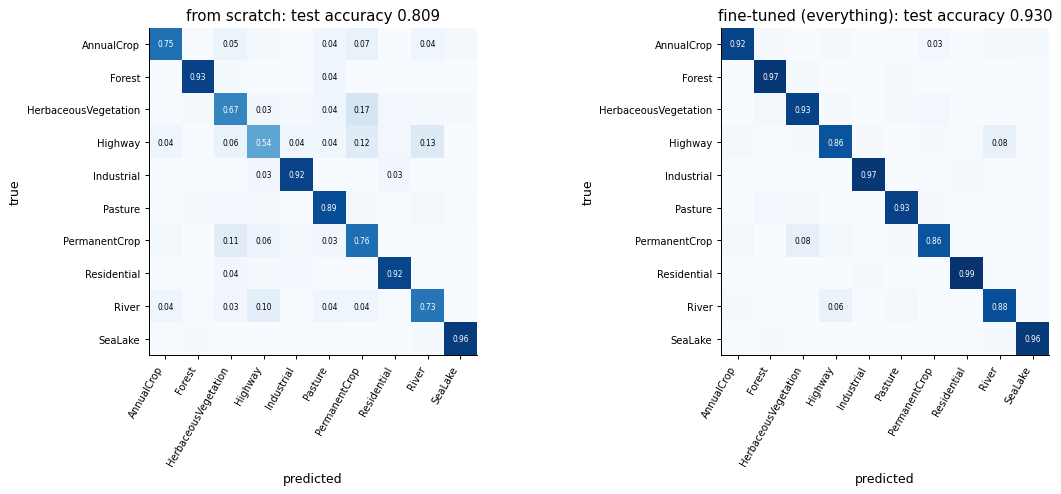

from scratch              most frequent confusions:  HerbaceousVegetation -> PermanentCrop (16%)   Highway -> River (13%)   Highway -> PermanentCrop (12%)
fine-tuned (everything)   most frequent confusions:  PermanentCrop -> HerbaceousVegetation (8%)   Highway -> River (8%)   River -> Highway (6%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
confusions = {}
for ax, (title, net) in zip(axes, [("from scratch", net_scratch), ("fine-tuned (everything)", net_full)]):
    _, acc, preds = evaluate(net, test_idx, return_preds=True)
    cm = confusion_matrix(y[test_idx], preds, normalize="true"); confusions[title] = cm
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1); ax.grid(False)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(class_names, rotation=60, ha="right", fontsize=8); ax.set_yticklabels(class_names, fontsize=8)
    for i in range(10):
        for j in range(10):
            if cm[i, j] >= 0.03: ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=6,
                                       color="white" if cm[i, j] > 0.5 else "black")
    ax.set_title(f"{title}: test accuracy {acc:.3f}"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

for title, cm in confusions.items():
    off = cm - np.diag(np.diag(cm))
    worst = np.dstack(np.unravel_index(np.argsort(-off, axis=None)[:3], off.shape))[0]
    print(f"{title:25s} most frequent confusions:  " +
          "   ".join(f"{class_names[i]} -> {class_names[j]} ({off[i, j]:.0%})" for i, j in worst))

Both networks make the same *kind* of mistake, between visually similar classes: the herbaceous vegetation and the permanent crops, the highway and the river (both are long thin lines across a green background). What differs is how many: the scratch network, with little data to learn from, confuses these classes up to twice as often. Transfer learning does not remove the hard cases; it shrinks them.

## 13. How many labels do you need?

So far: 500 images. The central question of transfer learning is how the advantage depends on the amount of labelled data. We repeat three experiments (scratch, frozen backbone, full fine-tuning) with $k = 5, 10, 25, 50, 100, 250$ and $600$ images per class (50 to 6,000 images), fixed number of epochs per size, no validation-based selection, and report the test accuracy. For small $k$ the random choice of the images matters, so we average over 2 or 3 random subsets.

This is the slowest cell of the lab (about 5 to 10 minutes on a T4).

In [19]:
RUN_SWEEP = True
sizes = [5, 10, 25, 50, 100, 250, 600]
reps = {5: 3, 10: 3, 25: 2, 50: 2, 100: 1, 250: 1, 600: 1}
ep_scratch = {5: 150, 10: 120, 25: 80, 50: 60, 100: 50, 250: 40, 600: 25}
ep_tuned = {5: 40, 10: 30, 25: 20, 50: 15, 100: 12, 250: 10, 600: 8}

def run_once(method, k, seed):
    tr = subset(k, seed)
    torch.manual_seed(seed)
    net = make_resnet(pretrained=method != "scratch")
    if method == "scratch":
        fit(net, tr, ep_scratch[k], [{"params": net.parameters(), "lr": 1e-3}], track=False, verbose=False)
    elif method == "frozen":
        freeze(body_params(net))
        fit(net, tr, 2 * ep_tuned[k], [{"params": head_params(net), "lr": 1e-2}], bn_eval=True, track=False, verbose=False)
    else:
        fit(net, tr, ep_tuned[k], [{"params": body_params(net), "lr": 1e-4}, {"params": head_params(net), "lr": 1e-3}],
            track=False, verbose=False)
    return evaluate(net, test_idx)[1]

sweep = {m: [] for m in ("scratch", "frozen", "everything")}
if RUN_SWEEP:
    t0 = time.time()
    for k in sizes:
        for m in sweep:
            sweep[m].append(np.mean([run_once(m, k, s) for s in range(reps[k])]))
        print(f"k = {k:3d} ({10 * k:5d} images)   " + "   ".join(f"{m} {sweep[m][-1]:.3f}" for m in sweep) +
              f"      [{time.time() - t0:.0f} s]")

k =   5 (   50 images)   scratch 0.482   frozen 0.726   everything 0.750      [5 s]


k =  10 (  100 images)   scratch 0.619   frozen 0.812   everything 0.841      [12 s]


k =  25 (  250 images)   scratch 0.753   frozen 0.859   everything 0.901      [18 s]


k =  50 (  500 images)   scratch 0.813   frozen 0.878   everything 0.929      [27 s]


k = 100 ( 1000 images)   scratch 0.852   frozen 0.894   everything 0.948      [34 s]


k = 250 ( 2500 images)   scratch 0.892   frozen 0.904   everything 0.958      [47 s]


k = 600 ( 6000 images)   scratch 0.945   frozen 0.921   everything 0.973      [69 s]


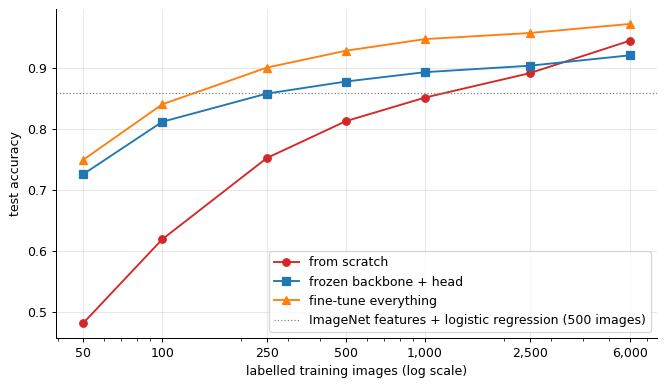

In [20]:
if RUN_SWEEP:
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    for m, label, st in [("scratch", "from scratch", "C3o-"), ("frozen", "frozen backbone + head", "C0s-"),
                         ("everything", "fine-tune everything", "C1^-")]:
        ax.plot(10 * np.array(sizes), sweep[m], st, label=label)
    ax.axhline(zero_train["ImageNet weights"], color="gray", ls=":", lw=1, label="ImageNet features + logistic regression (500 images)")
    ax.set_xscale("log"); ax.set_xlabel("labelled training images (log scale)"); ax.set_ylabel("test accuracy")
    ax.set_xticks([50, 100, 250, 500, 1000, 2500, 6000]); ax.set_xticklabels([50, 100, 250, 500, "1,000", "2,500", "6,000"])
    ax.legend(); plt.tight_layout(); plt.show()

Three regimes:

- **Very few labels** (5 to 10 per class): with 50 images the fine-tuned network reaches about 75 % and the scratch network about 50 %. The frozen backbone is almost as good as fine-tuning here (73 %): with so few images there is little to gain from adapting millions of weights.
- **A few hundred labels**: the gap is still 7 to 15 points. Fine-tuning with 250 images (90 %) is already as good as training from scratch on 2,500 (about 89 %), and fine-tuning with 1,000 images (95 %) matches scratch with 6,000 (94.5 %): here pre-training is worth about 10 times more labels.
- **Thousands of labels**: the gap shrinks to 3 points at 6,000 images, and the scratch network overtakes the frozen backbone (94.5 % against 92 %): features that were never adapted are a ceiling, while a network trained on enough data builds better ones. Fine-tuning is still ahead of both, so starting from good weights did not hurt here.

The advantage of pre-training is largest where labels are scarce, which is where most real projects live. The frozen backbone is the best value with the fewest labels, and is overtaken by full fine-tuning as soon as there are enough images to adapt the features.

## 14. Three ways to break a fine-tune

Transfer learning is robust, but not foolproof. Each of these mistakes is easy to make and it fails *silently*: no error, just a worse model (notes 03, sections 13.2 and 19.7).

**1. A learning rate that is too large.** Fine-tune everything with one learning rate $\alpha$, for several values. Too small and the model barely moves; too large and the first steps destroy the pre-trained features, which then have to be relearned from 500 images.

learning rate 1e-05:  test accuracy 0.567


learning rate 3e-05:  test accuracy 0.859


learning rate 1e-04:  test accuracy 0.926


learning rate 3e-04:  test accuracy 0.943


learning rate 1e-03:  test accuracy 0.934


learning rate 3e-03:  test accuracy 0.916


learning rate 1e-02:  test accuracy 0.639


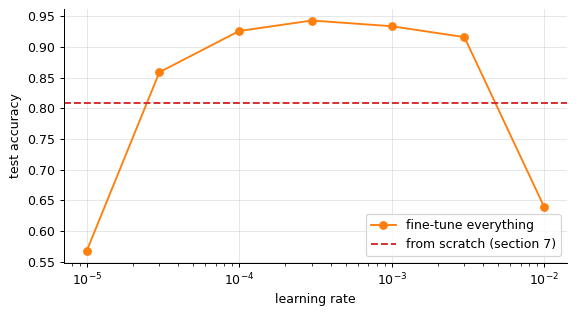

In [21]:
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
lr_acc = []
for lr in lrs:
    torch.manual_seed(0)
    net = make_resnet(pretrained=True)
    fit(net, train_idx, 15, [{"params": net.parameters(), "lr": lr}], track=False, verbose=False)
    lr_acc.append(evaluate(net, test_idx)[1])
    print(f"learning rate {lr:.0e}:  test accuracy {lr_acc[-1]:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.semilogx(lrs, lr_acc, "C1o-", label="fine-tune everything")
ax.axhline(evaluate(net_scratch, test_idx)[1], color="C3", ls="--", label="from scratch (section 7)")
ax.set_xlabel("learning rate"); ax.set_ylabel("test accuracy"); ax.legend(); plt.tight_layout(); plt.show()

A U-shaped curve with a broad flat top around $10^{-4}$ to $10^{-3}$. At $10^{-2}$, the learning rate that is reasonable *from scratch*, the pre-trained network ends up **worse than the scratch one**: it forgot what it knew. Fine-tuning needs a learning rate 10 to 100 times smaller than training from scratch.

**2. Forgetting the ImageNet normalisation, and 3. letting a frozen backbone's BatchNorm layers drift.** Both show most clearly with a frozen backbone, where the features cannot adapt. We repeat the experiment of section 8 with each mistake.

In [22]:
def frozen_run(normalize=True, bn_eval=True):
    torch.manual_seed(0)
    net = make_resnet(pretrained=True)
    freeze(body_params(net))
    fit(net, train_idx, 30, [{"params": head_params(net), "lr": 1e-2}], bn_eval=bn_eval, normalize=normalize,
        track=False, verbose=False)
    return evaluate(net, test_idx, normalize=normalize)[1]

pit = {"correct (section 8)": frozen_run(),
       "no ImageNet normalisation": frozen_run(normalize=False),
       "BatchNorm statistics updated (bn_eval=False)": frozen_run(bn_eval=False)}
for name, acc in pit.items():
    print(f"{name:46s} test accuracy {acc:.3f}")

correct (section 8)                            test accuracy 0.876
no ImageNet normalisation                      test accuracy 0.828
BatchNorm statistics updated (bn_eval=False)   test accuracy 0.849


- **Without the normalisation** the inputs are on a different scale from the one the filters were trained for. Every activation is shifted, the features mean something else, and accuracy drops, even though the images look fine to a human.
- **With `bn_eval=False`**, a "frozen" backbone is not frozen: in training mode each BatchNorm layer keeps updating its running mean and variance with the statistics of the current mini-batch. With batches from a small training set those statistics are noisy, and the features move under the head's feet. (Re-estimating the statistics on purpose, on enough target images, can help; see AdaBN in notes 03.)

## 15. Summary and exercises

- Pre-trained and scratch networks have **the same architecture**; they differ in the starting weights. ImageNet weights encode edges, colours and textures that transfer even to satellite images.
- **Zero training** (pre-trained features + logistic regression) is a strong baseline. **Feature extraction** (frozen backbone, new head) is the cheapest and best with very few labels; **fine-tuning** (small learning rate, discriminative rates, warm-up) is best once there are some hundreds of labels. Fine-tuning moves the early layers very little, and the deep ones the most.
- The advantage of pre-training is **largest when labels are scarce** and shrinks as the labelled set grows; the more different the target domain, the more layers you need to adapt.
- The silent failures: a learning rate as large as for scratch training, a missing ImageNet normalisation, BatchNorm statistics drifting in a frozen backbone.
- Procedure: baseline with frozen features → fine-tune with a small learning rate → compare with scratch on the **same validation set** → report the test set once.

Next in this chapter: the multi-task demo (one backbone, several heads), and the object-detection lab, which fine-tunes a pre-trained YOLO11 detector in exactly the same spirit.

### Exercises

Try each one before opening the answer.

1. **Counting.** How many parameters does each of the strategies of sections 8 and 9 train (head only; `layer4` + head; everything)? Check them against `count_params`. What fraction of the network does feature extraction train?
2. **Why the last layers change most.** Explain, with what you know about the features of a CNN, why the relative weight change in section 11 grows with depth.
3. **Warm-up.** The one-cycle schedule starts with a tiny learning rate. Why is this particularly important for fine-tuning, where the head is random and the backbone is good?
4. **Augmentation.** We used flips and quarter turns. Which augmentations would you use for (a) photos of cats and dogs, (b) chest X-rays, (c) handwritten digits? Which would be *wrong*?
5. **Choosing a strategy.** With the decision guide of notes 03 (section 13.1), what would you do for (a) 300 photos of two kinds of ants, (b) 3,000 chest X-rays, (c) 500,000 satellite images?
6. **An experiment to try.** Replace ResNet-18 by ResNet-50 or by `efficientnet_b0` (`torchvision.models`). Does the ranking of the strategies change? Does the size of the model change the number of labels needed?

<details>
<summary><b>Answers</b></summary>

**1.** Head only: $512 \cdot 10 + 10 = 5{,}130$ (0.05 % of the 11.2 M). `layer4` + head: about 8.4 M (`layer4` has two blocks with 512 channels, most of the network). Everything: 11,181,642. Feature extraction trains 5,130 parameters, yet it already gets most of the way: the features do the work.

**2.** Early layers detect edges, colours and simple textures, which are the same in every kind of image: there is little to change. Later layers combine them into parts and objects specific to the training task (ImageNet's dogs and cars); on satellite images those combinations have to be rebuilt, so their weights move more. The same asymmetry is why "freeze the early layers" is the standard recipe for small datasets.

**3.** At the start the head is random, so the loss is large and its gradients, which flow back into the whole backbone, are large and meaningless. With a normal learning rate those first steps would overwrite good features with noise (section 14, the learning rate of $10^{-2}$). A tiny learning rate lets the head become reasonable first; only then the backbone is nudged by useful gradients. The alternative is "train the head first, then unfreeze".

**4.** (a) Cats and dogs: horizontal flips, small rotations, crops, brightness; no vertical flips (animals are not upside down). (b) Chest X-rays: small rotations and shifts, brightness and contrast; a horizontal flip moves the heart to the other side of the image, which creates anatomically impossible images, so not that. (c) Digits: small rotations and shifts; no flips (a mirrored 2 is not a 2; 6 and 9 swap under a 180° rotation). Satellite images are the exception: no "up", so flips and quarter turns are free. The rule is the one of the CNN lab: the transformation must not change the label.

**5.** (a) 300 images, target close to ImageNet (ants are in ImageNet): feature extraction, maybe unfreezing the last block. (b) 3,000 images in a different domain: fine-tune most of the network with a small learning rate; early layers can stay frozen; look for a medical pre-trained model if there is one. (c) 500,000 images: fine-tune everything; pre-training still speeds up convergence, and training from scratch becomes a serious option with this much data.

**6.** Bigger pre-trained models usually have better features, so the frozen and fine-tuned curves move up, mostly at small $k$; from scratch, a bigger model needs even more data. The ordering of the strategies at $k = 50$ rarely changes: pre-trained beats scratch, and fine-tuning beats the frozen backbone once there are a few hundred images.

</details>